Loaded 10324 triples
Graph built: 3116 nodes, 6553 edges

--- Scale-free diagnostic ---
Slope (power law exponent, negative): -1.476
R-squared of log-log fit: 0.851
p-value: 1.271e-30
Verdict: Consistent with a scale-free (power law) distribution


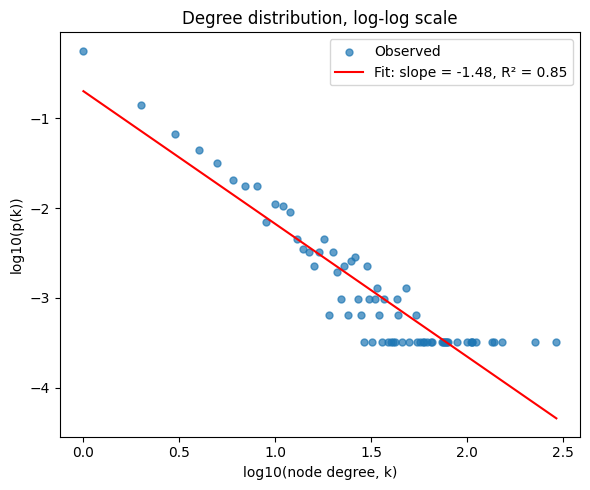

Saved plot to scale_free_loglog.png
Saved degree distribution and top hubs to degree_distribution.xlsx


In [1]:
"""
Scale-free structure check for the extracted triple knowledge graph.

Builds a graph from (source, target) pairs, computes the node degree
distribution, and tests whether log(p(k)) vs log(k) is linear with a
negative slope, the standard diagnostic used in PlantConnectome (Mutwil
et al. 2010) and general network science.

Designed for Jupyter/Colab execution. No __main__ guard.
Set RUN_MODE and the input path below, then run all cells.
"""

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
RUN_MODE = "full"  # "full" or "exclude_flagged"

TRIPLES_PATH = "phase2_terra_full_triples_categorized.xlsx"
SOURCE_COL = "source"
TARGET_COL = "target"
NEEDS_REVIEW_COL = "needs_review"      # not present in this file; exclude_flagged mode will just be skipped

GRAPH_TYPE = "undirected"              # "undirected" or "directed"
OUTPUT_XLSX = "degree_distribution.xlsx"
OUTPUT_PLOT = "scale_free_loglog.png"

# ---------------------------------------------------------------
# LOAD TRIPLES
# ---------------------------------------------------------------
def load_triples(path):
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    elif path.endswith(".xlsx"):
        return pd.read_excel(path)
    elif path.endswith(".csv"):
        return pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file type: {path}")


df = load_triples(TRIPLES_PATH)
print(f"Loaded {len(df)} triples")

if RUN_MODE == "exclude_flagged" and NEEDS_REVIEW_COL in df.columns:
    before = len(df)
    df = df[df[NEEDS_REVIEW_COL] != True]  # noqa: E712
    print(f"Excluded {before - len(df)} rows flagged needs_review")

df = df.dropna(subset=[SOURCE_COL, TARGET_COL])

# ---------------------------------------------------------------
# BUILD GRAPH
# ---------------------------------------------------------------
G = nx.DiGraph() if GRAPH_TYPE == "directed" else nx.Graph()

for _, row in df.iterrows():
    G.add_edge(str(row[SOURCE_COL]).strip(), str(row[TARGET_COL]).strip())

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ---------------------------------------------------------------
# DEGREE DISTRIBUTION
# ---------------------------------------------------------------
if GRAPH_TYPE == "directed":
    degrees = [d for _, d in G.degree()]  # total degree (in + out)
else:
    degrees = [d for _, d in G.degree()]

degree_series = pd.Series(degrees)
degree_counts = degree_series.value_counts().sort_index()

k = degree_counts.index.values.astype(float)
count_k = degree_counts.values.astype(float)
p_k = count_k / count_k.sum()

# drop k = 0 (undefined on log scale, and not meaningful for this test)
mask = k > 0
k, p_k = k[mask], p_k[mask]

log_k = np.log10(k)
log_pk = np.log10(p_k)

# ---------------------------------------------------------------
# LINEAR FIT ON LOG-LOG SCALE
# ---------------------------------------------------------------
slope, intercept, r_value, p_value, std_err = stats.linregress(log_k, log_pk)

print("\n--- Scale-free diagnostic ---")
print(f"Slope (power law exponent, negative): {slope:.3f}")
print(f"R-squared of log-log fit: {r_value**2:.3f}")
print(f"p-value: {p_value:.4g}")

if slope < 0 and r_value**2 >= 0.85:
    verdict = "Consistent with a scale-free (power law) distribution"
elif slope < 0:
    verdict = "Negative slope, but weak linear fit; scale-free structure not strongly supported"
else:
    verdict = "Not consistent with a scale-free distribution"

print(f"Verdict: {verdict}")

# ---------------------------------------------------------------
# PLOT
# ---------------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(log_k, log_pk, s=25, alpha=0.7, label="Observed")
fit_line = intercept + slope * log_k
plt.plot(log_k, fit_line, color="red", linewidth=1.5,
          label=f"Fit: slope = {slope:.2f}, R² = {r_value**2:.2f}")
plt.xlabel("log10(node degree, k)")
plt.ylabel("log10(p(k))")
plt.title("Degree distribution, log-log scale")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=200)
plt.show()
print(f"Saved plot to {OUTPUT_PLOT}")

# ---------------------------------------------------------------
# SAVE DEGREE DISTRIBUTION TABLE
# ---------------------------------------------------------------
top_hubs = (
    pd.DataFrame({"node": list(dict(G.degree()).keys()),
                  "degree": list(dict(G.degree()).values())})
    .sort_values("degree", ascending=False)
    .reset_index(drop=True)
)

with pd.ExcelWriter(OUTPUT_XLSX) as writer:
    pd.DataFrame({"k": k, "p_k": p_k, "log_k": log_k, "log_pk": log_pk}).to_excel(
        writer, sheet_name="degree_distribution", index=False
    )
    top_hubs.head(50).to_excel(writer, sheet_name="top_50_hubs", index=False)
    pd.DataFrame({
        "metric": ["slope", "r_squared", "p_value", "n_nodes", "n_edges", "verdict"],
        "value": [slope, r_value**2, p_value, G.number_of_nodes(), G.number_of_edges(), verdict],
    }).to_excel(writer, sheet_name="summary", index=False)

print(f"Saved degree distribution and top hubs to {OUTPUT_XLSX}")